In [1]:
import torch
import random
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
import numpy as np
import pickle
import matplotlib.pyplot as plt
from IPython.display import clear_output
from NO import *
from special_loss_functions import *

random.seed(100)
device = "cpu"

In [2]:
def train(dataloader, model, loss_fn, optimizer, device = "cpu"):
    num_batches = len(dataloader)
    model.train()
    train_loss = 0
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)     
        pred = model(X)
        loss = loss_fn(pred, y)
        train_loss += loss.item()
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    loss /= num_batches
    return loss

def test(dataloader, model, loss_fn, device = "cpu"):
    num_batches = len(dataloader)
    model.eval()
    loss = 0
    with torch.no_grad():   
        for batch, (X,y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)
            pred = model(X)
            loss += loss_fn(pred, y).item()
    loss /= num_batches
    return loss

In [3]:
def make_training_testing_datasets(data, history, batch_size):

    # select
    features = torch.tensor(data[:-history, :])
    labels = [torch.tensor(data[i:i+history, :]).t() for i in range(len(data)-history)]

    # re-arrange
    features = torch.reshape(features, features.shape + (1,)).to(torch.float32)
    labels = torch.stack(labels)
    labels = torch.reshape(labels, labels.shape + (1,)).to(torch.float32)

    # create datasets
    training_size = 1024
    idx = torch.randperm(training_size)
    training_dataset = TensorDataset(features[idx, :, :], labels[idx, :, :, :])
    testing_dataset = TensorDataset(features[training_size:, :, :], labels[training_size:, :, :, :])

    # create dataloaders
    training_dataloader = DataLoader(training_dataset, batch_size=batch_size, shuffle=True)
    testing_dataloader = DataLoader(testing_dataset, batch_size=batch_size, shuffle=True)

    dimensions = labels.shape
    
    return training_dataloader, testing_dataloader, dimensions

In [4]:
# Load PDE solution
with open('data/KuramotoSivashinsky/KS_N32.pkl', 'rb') as file:
    data = pickle.load(file)

In [5]:
def make_training_testing_datasets(data, history, batch_size):
    # select
    features = torch.tensor(data[:-history, :])
    labels = [torch.tensor(data[i+1:i+history+1, :]).t() for i in range(len(data)-history)]

    # re-arrange
    features = torch.reshape(features, features.shape + (1,)).to(torch.float32)
    labels = torch.stack(labels)
    labels = torch.reshape(labels, labels.shape + (1,)).to(torch.float32)

    print(features.shape)
    print(labels.shape)

    # create datasets
    training_size = 1000
    idx = torch.randperm(training_size)
    training_dataset = TensorDataset(features[idx, :, :], labels[idx, :, :, :])
    testing_dataset = TensorDataset(features[training_size:, :, :], labels[training_size:, :, :, :])

    # create dataloaders
    training_dataloader = DataLoader(training_dataset, batch_size=batch_size, shuffle=True)
    testing_dataloader = DataLoader(testing_dataset, batch_size=batch_size, shuffle=True)

    dimensions = labels.shape
    
    return training_dataloader, testing_dataloader, dimensions

In [6]:
# create data structures
history = 5
batch_size = 64
training_dataloader, testing_dataloader, dimensions = make_training_testing_datasets(data, history, batch_size)

torch.Size([1996, 32, 1])
torch.Size([1996, 32, 5, 1])


In [7]:
# initialize operator
Nf = dimensions[-1]
Nx = dimensions[1]
Nlifted = 8
Nk_truncated = 2 # 2 works quite well
depth = history

neuralop = PWNO(
            (Nx, Nf), 
            Nlifted, 
            (Nk_truncated,), 
            depth, wavelet='db4'
            ).to(device) 


total_params = sum(p.numel() for p in neuralop.parameters())
print(total_params)


loss_fn_test = torch.nn.MSELoss(reduction='mean')
loss_fn = H1Loss(reduction='mean', dim=1) # dim=1 only computes spatial norm. None: the error includes the temporal dimension

rate = 2e-04
optimizer_neuralop = torch.optim.Adam(neuralop.parameters(), lr=rate)

31385


In [8]:
# train
testing_loss = []
training_loss = []
epochs = 500
for i in range(epochs):
    training_loss += [train(training_dataloader, neuralop, loss_fn, optimizer_neuralop)]
    testing_loss += [test(testing_dataloader, neuralop, loss_fn_test)]
    if i%100==0:
        print(f"Train Loss: {(training_loss[-1]):>0.5f}, Test Loss: {(testing_loss[-1]):>0.5f}")        
        rate *= 0.8
        optimizer_neuralop = torch.optim.Adam(neuralop.parameters(), lr=rate)
print(f'final learning rate: {rate}')
plt.figure()
plt.plot(testing_loss)
plt.loglog()


Train Loss: 0.10210, Test Loss: 1.19473
Train Loss: 0.02819, Test Loss: 0.25488
Train Loss: 0.00416, Test Loss: 0.02633
Train Loss: 0.00372, Test Loss: 0.01779
Train Loss: 0.00363, Test Loss: 0.01689


KeyboardInterrupt: 

In [9]:
# Apply model on higher prediction data
# first, load the data
with open('data/KuramotoSivashinsky/KS_N128.pkl', 'rb') as file:
    data_hr = pickle.load(file)

# create data structures
history = 5
batch_size = 64
training_dataloader_hr, testing_dataloader_hr, dimensions = make_training_testing_datasets(data_hr, history, batch_size)

Nx_hr = dimensions[1]

torch.Size([1996, 128, 1])
torch.Size([1996, 128, 5, 1])


In [10]:
# X: batch of tensors
# Nx: target resolution (smaller)
# TO DO: upsample/ downsample with wavelets
def fft_downsample(X, Nx):
    X = torch.fft.rfft(X, dim=1, norm="backward")
    return torch.fft.irfft(X[:, :Nx//2+1, :], dim=1, norm="backward")

def fft_upsample(X, Nx, Nx_hr):
    Xsize = X.shape
    
    X = torch.fft.rfft(X, dim=1, norm="backward")
    X = torch.cat((X[:, :Nx//2+1, :, :], torch.zeros((Xsize[0], Nx_hr//2-Nx//2) + Xsize[2:])), 1)
    X = torch.fft.irfft(X, dim=1, norm="backward")
    return X

# downsample, predict, upsample
def test_hr(dataloader, model, loss_fn, Nx):
    num_batches = len(dataloader)
    model.eval()
    loss = 0
    with torch.no_grad():   
        for batch, (X,y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)
            Nx_hr = X.size()[1]
            batch_size = X.size()[0]

            # downsample
            X = fft_downsample(X, Nx)

            
            # predict
            pred = model(X).detach()

            # upsample
            pred = fft_upsample(pred, Nx, Nx_hr)

            # loss
            loss += loss_fn(pred, y).item()
            
    loss /= num_batches
    return loss

In [11]:
# compare different implementations
neuralop_f = FNO(
            (Nx, Nf), 
            16, 
            (10,), 
            depth
            ).to(device) 
neuralop_f.load_state_dict(torch.load("FNO.pth")) # saved by running FNO_test notebook

neuralop_p = PFNO(
            (Nx, Nf), 
            16, 
            (10,), 
            depth
            ).to(device) 
neuralop_p.load_state_dict(torch.load("PFNO.pth")) # saved by running FNO_test notebook


print(f'WNO: {test_hr(testing_dataloader_hr, neuralop, loss_fn, Nx)}')
print(f'FNO: {test_hr(testing_dataloader_hr, neuralop_f, loss_fn, Nx)}')
print(f'PFNO: {test_hr(testing_dataloader_hr, neuralop_p, loss_fn, Nx)}')

WNO: 0.016262943274341524
FNO: 0.13181740418076515
PFNO: 0.002691846282687038


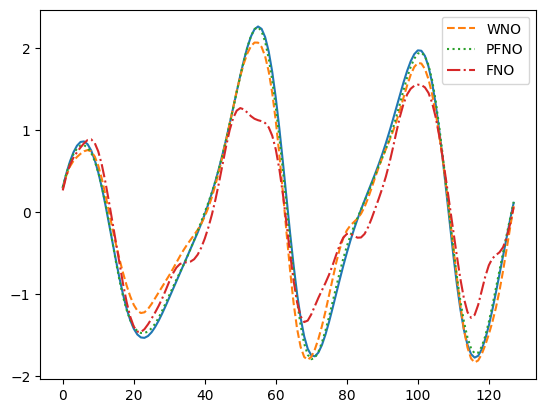

KeyboardInterrupt: 

In [14]:
# plot results
neuralop.eval()
neuralop_p.eval()
neuralop_f.eval()
data_hr = torch.tensor(data_hr)
for i in range(data_hr.size()[0]):
    uin = torch.reshape(data_hr[i, :].to(torch.float32), (1, Nx_hr, 1))
    # downsample
    uin = torch.fft.rfft(uin, dim=1, norm="backward")
    uin = uin[:, :Nx//2+1, :]
    uin = torch.fft.irfft(uin, dim=1, norm="backward")

    # predict
    u_pred = neuralop(uin).detach()
    u_pred2 = neuralop_p(uin).detach()
    u_pred3 = neuralop_f(uin).detach()

    # upsample
    pred_size = u_pred.shape
    u_pred = torch.fft.rfft(u_pred, dim=1, norm="backward")
    u_pred = torch.cat((u_pred[:, :Nx//2+1, :], torch.zeros((1, Nx_hr//2-Nx//2) + pred_size[2:])), 1)
    u_pred = torch.fft.irfft(u_pred, dim=1, norm="backward")

    u_pred2 = torch.fft.rfft(u_pred2, dim=1, norm="backward")
    u_pred2 = torch.cat((u_pred2[:, :Nx//2+1, :], torch.zeros((1, Nx_hr//2-Nx//2) + pred_size[2:])), 1)
    u_pred2 = torch.fft.irfft(u_pred2, dim=1, norm="backward")

    u_pred3 = torch.fft.rfft(u_pred3, dim=1, norm="backward")
    u_pred3 = torch.cat((u_pred3[:, :Nx//2+1, :], torch.zeros((1, Nx_hr//2-Nx//2) + pred_size[2:])), 1)
    u_pred3 = torch.fft.irfft(u_pred3, dim=1, norm="backward")
    
    clear_output(wait=True)
    fig, ax = plt.subplots()
    
    ax.plot(data_hr[i+history, :])
    ax.plot(u_pred.detach().numpy().squeeze()[:, -1], '--', label='WNO')
    ax.plot(u_pred2.detach().numpy().squeeze()[:, -1], ':', label='PFNO')
    ax.plot(u_pred3.detach().numpy().squeeze()[:, -1], '-.', label='FNO')
    plt.legend()
    plt.show()
    plt.pause(0.1)